## 0. Computer vision libraries in pytorch  

* `torchvision` - base domain library for pytorch computer vision
* `torchvision.datasets` - get datasets and data loading function for computer vision
* `torchvision.models` - get pretrained computer vision models that you can leverage for your own problems
* `torchvision.transform` - function for manipulating your vision data (images) to be suitable for use with ml models
* `torch.utils.data.datasets` - base dataset class for Pytorch
* `torch.utils.data.DataLoader` - Create the python iterable over a dataset

In [208]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.5.1
0.20.1


## 1. Getting the dataset 

The dataset we are using is the FashionMNIST from torchvision.datasets

In [209]:
#setup training data
from torchvision import datasets
train_data = datasets.FashionMNIST(
                                    root="data", # where to download the data?
                                    train=True, # do we want the training dataset?
                                    download=True, # do we want to download yes/no ?
                                    transform=torchvision.transforms.ToTensor(), # How dow we want to transform the data?
                                    target_transform=None # how do we want to transform the labels/targets
)

test_data = datasets.FashionMNIST(
                                root="data",
                                train=False,
                                download=True,
                                transform=ToTensor(),
                                target_transform=None
)

In [210]:
len(train_data),len(test_data)

(60000, 10000)

In [211]:
# see the first training examples
image, labels = train_data[0]
image, labels

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [212]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [213]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [214]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [215]:
# Check the shape of our images
print(f"Image shape :{image.shape} -> [color_channels, height,width]")
print(f"Image labels: {class_names[labels]}")    

Image shape :torch.Size([1, 28, 28]) -> [color_channels, height,width]
Image labels: Ankle boot


### 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, 'Ankle boot')

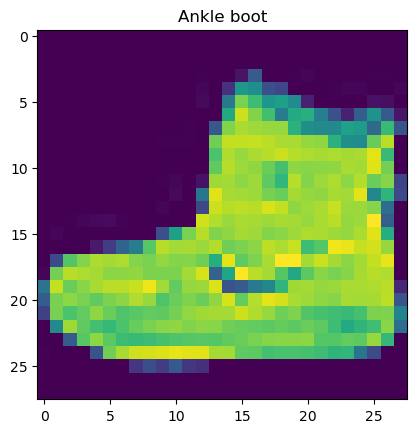

In [216]:
import matplotlib.pyplot as plt
image,label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(class_names[label])

Text(0.5, 1.0, 'Ankle boot')

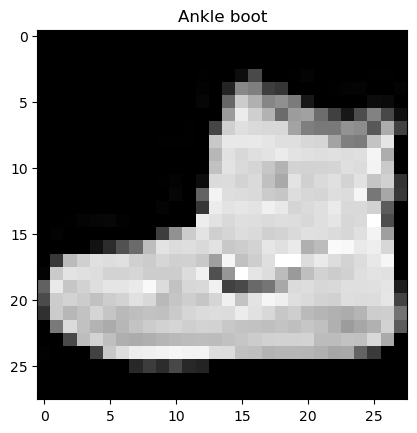

In [217]:
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])

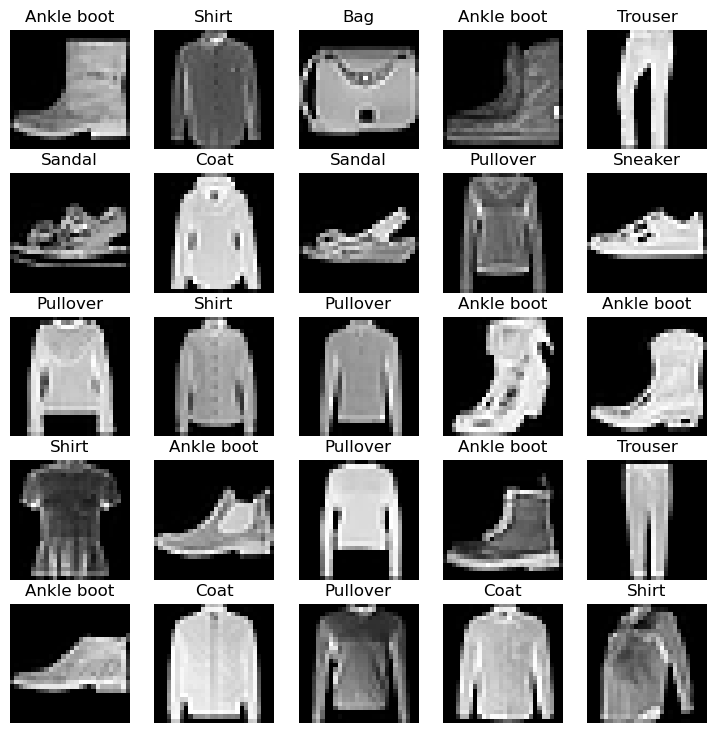

In [218]:
# Plot more images 

torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 5,5 
for i in range(1,rows*cols+1):
    random_idx = torch.randint(0,len(train_data), size=[1]).item() 
    '''What happens:
    torch.randint(0, len(train_data))
    → random number between 0 and 60000
    size=[1]
    → returns tensor like [12345]
    .item()
    → converts tensor → integer'''
    img,label = train_data[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze(),cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

Do you think these items of clothing (images) could be modelled with pure linear lines? or do you think we will need non linearity ??

## 2. Prepare DataLoader

Right now, our data is in the form of pytorch datasets.  

Datalaoder turns our datasets into a Python Iterable.

More specifically, we want to turn our data into batches(or mini batches).  

Why would we do this?  

1. It is more computationally efficient, as in your computing hardware may not be able to look (store in memory) at 60000 images in one hit. so we break it down to 32 images at a time (batch size of 32).  

2. It gives our neural network more chances to update its gradienta per epoch. 

In [219]:
from torch.utils.data import DataLoader

#setup the batch size hyperparameter

BATCH_SIZE = 32

#Turn dataset into iterables (batches)
train_dataloader = DataLoader(
                            dataset=train_data,
                            batch_size=BATCH_SIZE,
                            shuffle= True
)

test_dataloader = DataLoader(
                             dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)




In [220]:
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x21a55613190>,
 <torch.utils.data.dataloader.DataLoader at 0x21a159bb990>)

In [221]:
# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x0000021A55613190>, <torch.utils.data.dataloader.DataLoader object at 0x0000021A159BB990>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [222]:
# check out whats inside the training dataloader
train_feature_batch, train_labels_batch = next(iter(train_dataloader))
train_feature_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
labels: 1, label size: torch.Size([])


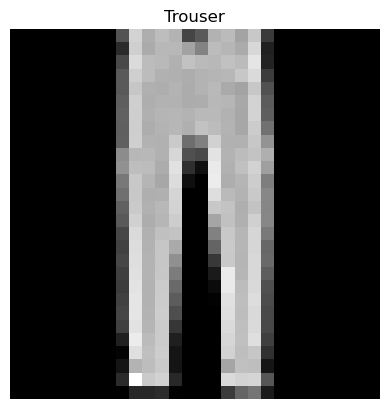

In [223]:
# show a sample

torch.manual_seed(42)
random_idx = torch.randint(0,len(train_feature_batch), size=[1]).item() 
img,label = train_feature_batch[random_idx],train_labels_batch[random_idx]
fig.add_subplot(rows,cols,i)
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)

print(f"Image size: {img.shape}")
print(f"labels: {label}, label size: {label.shape}")

## 3. Model 0: Build a baseline model 

When starting to build a series of machine learning modelling experiments, its best practice to start with a baseline model. 

A baseline model is a simple model you will try and improve upon with subsequent models. 

In other words: start simply and add complexity when necessary

In [224]:
# Creating the flatten layer
flatten_model = nn.Flatten()

# Get a single sample

x = train_feature_batch[0]

#flatten the sample
output = flatten_model(x)

# Print out what happening 
print(f"Shape before flatenning:{x.shape} -> [color_channel,height,width]") 
print(f"Shape after flatenning: {output.shape} -> [color_channel,height*width]")

Shape before flatenning:torch.Size([1, 28, 28]) -> [color_channel,height,width]
Shape after flatenning: torch.Size([1, 784]) -> [color_channel,height*width]


In [225]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self,
                 input_shape:int,
                 hidden_units:int,
                 output_shape:int):
        super().__init__()
        self.linear_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=output_shape)
        
        )

    def forward(self,x):
        return self.linear_stack(x)
    

In [226]:
torch.manual_seed(42)


#setup model with input paramters

model_0 = FashionMNISTModelV0(
    input_shape= 784, # 28 x 28
    hidden_units= 10,
    output_shape=len(class_names)
)

model_0.to("cpu")

model_0

FashionMNISTModelV0(
  (linear_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [227]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [228]:
model_0.state_dict()

OrderedDict([('linear_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('linear_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('linear_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, 

### 3.1 setup loss, optimizer and evaluation metrics

* Loss function - Since we are working with multi-class data, our loss function will `nn.CrossEntropyLoss()`
* Optimizer -  our optimizer `torch.optim.SGD()`
* Evaluation metric - since we are walking on a classification problem, lets use accuracy as our evaluation metric  

In [229]:
import requests
from pathlib import Path

# Download the helper functions from Learn pytorch repo.

if Path("helper_function.py").is_file():
    print("helper_functions.py is exists")

else:
    print(" Download the helper_function.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py","wb") as f:
        f.write(request.content)


 Download the helper_function.py


In [230]:
model_0.parameters

<bound method Module.parameters of FashionMNISTModelV0(
  (linear_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)>

In [231]:
# Import accuracy metric
from helper_functions import accuracy_fn

# setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
                            params=model_0.parameters(),
                            lr =0.1)


### 3.2 Creating a function to time our experiments

Machine learning is very experimental.  

Two of the main things you will often want to track are:
1. Model's performance(loss and accuracy values)
2. How fast it runs

In [232]:
from  timeit import default_timer as timer

def print_train_time(start:float,
                     end:float,
                     device: torch.device = None):
    """Prints difference between start and end time"""
    total_time = end - start

    print(f"Train time on {device}: {total_time:.3f} seconds")

    return total_time

In [233]:
start_time = timer()
#some code
end_time = timer()
print_train_time(start=start_time,end=end_time,device="cpu")

Train time on cpu: 0.000 seconds


2.6399997295811772e-05

### 3.3 Creating the training loop and training a model on batch of data 
1. Loop through epochs 
2. Loop through training batches, perform training steps, calculate the train loss *per batch*.
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*
4. Print out what's happening.
5. Time it all 

In [234]:
# import tqdm for progress bar
from tqdm.auto import tqdm

# set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# set the number of epoch
epochs = 3

#Create training and test loop

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----")
    ### Training
    train_loss = 0
    # Add a loop to loop through the training batches
    for batch, (X,y) in enumerate(train_dataloader):
        model_0.train()

        y_pred = model_0(X)

        # calcualte the loss
        loss = loss_fn(y_pred,y)
        train_loss += loss # accumulate the train loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # print what happening
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

    # Divide total train loss by length of train dataloader
    train_loss /= len(train_dataloader)

    ### testing
    test_loss,test_acc = 0,0
    model_0.eval()

    with torch.inference_mode():
        for X_test,y_test in test_dataloader:
            test_pred = model_0(X_test)

            test_loss += loss_fn(test_pred,y_test)

            test_acc += accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))

        #calcualte the testloss
        test_loss /= len(test_dataloader)


        # calculate the test acc
        test_acc /= len(test_dataloader)

    print(f"\nTrain loss: {train_loss:.4f} | test_loss: {test_loss:.4f}, Test_acc: {test_acc:.4f} ")

# calculate the training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(
                                            start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device)
                                            )








  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 33%|███▎      | 1/3 [00:10<00:20, 10.27s/it]


Train loss: 0.5904 | test_loss: 0.5095, Test_acc: 82.0387 
Epoch: 1
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 67%|██████▋   | 2/3 [00:20<00:10, 10.45s/it]


Train loss: 0.4763 | test_loss: 0.4799, Test_acc: 83.1969 
Epoch: 2
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


100%|██████████| 3/3 [00:31<00:00, 10.46s/it]


Train loss: 0.4550 | test_loss: 0.4766, Test_acc: 83.4265 
Train time on cpu: 31.376 seconds


In [235]:
str(next(model_0.parameters()).device)

'cpu'

## 4.Make prediction and get Model 0 results

In [236]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):

    loss, acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            y_pred = model(X)

            
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss.item(),
        "model_acc": acc
    }

#Calculate model 0 result on test dataset
model_0_results = eval_model(
                            model=model_0,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn
)

model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## 5. setup the device agnostic code

In [237]:
device ="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1: Building the model with non linearity

In [238]:
# Create the model with non linear layers
class FashionMNISTModelV1(nn.Module):
    def __init__(self,
                 input_shape:int,
                 hidden_unit:int,
                 output_shape:int):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,
                      out_features=hidden_unit),
            nn.ReLU(),
            nn.Linear(in_features=hidden_unit,
                      out_features=output_shape),
            nn.ReLU()
            
        )

    def forward(self,x:torch.Tensor):
        return self.layer_stack(x)
    


In [239]:
next(model_0.parameters()).device

device(type='cpu')

In [240]:
#create the instance of model 1 
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(
                            input_shape= 784,
                            hidden_unit=10,
                            output_shape=len(class_names)).to(device)

In [241]:
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 setup loss, optimizer and evluation metrics

In [242]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), # tries to update our models parameter to reduce the loss
                            lr=0.1)

### 6.2 Functionizing training and evaluation/testing loops

In [243]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    model.train()
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

In [244]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [245]:
torch.manual_seed(42)

#measure time

from timeit import default_timer as Timer
train_time_start_on_gpu = timer()

#set epochs

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch:{epoch}\n-----------")

    train_step(model=model_1,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)
    
    test_step(model=model_1,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)
train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0
-----------
Train loss: 1.09199 | Train accuracy: 61.34%


 33%|███▎      | 1/3 [00:12<00:24, 12.29s/it]

Test loss: 0.95636 | Test accuracy: 65.00%

Epoch:1
-----------
Train loss: 0.78101 | Train accuracy: 71.93%


 67%|██████▋   | 2/3 [00:24<00:12, 12.29s/it]

Test loss: 0.72227 | Test accuracy: 73.91%

Epoch:2
-----------
Train loss: 0.67027 | Train accuracy: 75.94%


100%|██████████| 3/3 [00:36<00:00, 12.25s/it]

Test loss: 0.68500 | Test accuracy: 75.02%

Train time on cuda: 36.759 seconds


In [246]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [247]:
total_train_time_model_0

31.37599929999851

In [248]:
total_train_time_model_1

36.758538499998394

In [249]:
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device=device):

    loss, acc = 0, 0
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X,y = X.to(device),y.to(device)
            y_pred = model(X)

            
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

        loss /= len(data_loader)
        acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss.item(),
        "model_acc": acc
    }





In [250]:
# get model 1 results
model_1_results = eval_model(
                            model=model_1,
                            data_loader=test_dataloader,
                            loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn
)

model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008368492126,
 'model_acc': 75.01996805111821}

In [251]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

## Model 2: Building a Convolutional Neural Network(CNN)

CNN are also known as ConvNets

CNN are known for the capabilities to find pattern in visual data

In [252]:
# create a convolutional neural network

class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
    def forward(self,x):
        x = self.conv_block_1(x)
        #print(f"Output shape of the conv_block_1:{x.shape}")
        x = self.conv_block_2(x)
        #print(f"Output shape of the conv_block_2: {x.shape}")
        x =  self.classifier(x)
        #print(f"Output shape of the classifier: {x.shape}")
        return x
        

In [253]:
torch.manual_seed(42)

model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)

In [254]:
image.shape

torch.Size([1, 28, 28])

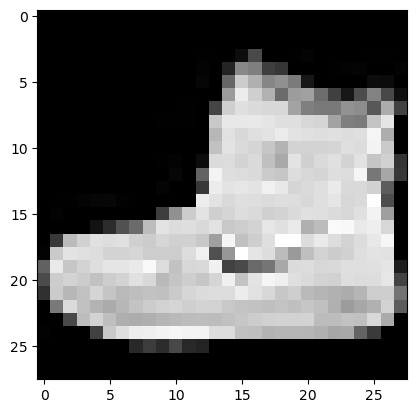

In [255]:
plt.imshow(image.squeeze(),cmap="gray")

In [256]:
rand_image_tensor = torch.randn(size=(1,1,28,28))
rand_image_tensor.shape

torch.Size([1, 1, 28, 28])

In [257]:
model_2(rand_image_tensor.to(device))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [258]:
model_2.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 0.2548,  0.2767, -0.0781],
                        [ 0.3062, -0.0730,  0.0673],
                        [-0.1623,  0.1958,  0.2938]]],
              
              
                      [[[-0.2445,  0.2897,  0.0624],
                        [ 0.2463,  0.0451,  0.1607],
                        [-0.0471,  0.2570,  0.0493]]],
              
              
                      [[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
      

### 7.1 stepping through `nn.Conv2d()`



In [259]:
torch.manual_seed(42)
# create the batch of images

image = torch.randn(size=(32,3,64,64))
test_image = image[0]

print(f"Image batch shape: {image.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image:\n {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

In [260]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0)

conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 62, 62])

### 7.2 stepping through `nn.MaxPool2d`

In [261]:
test_image.shape

torch.Size([3, 64, 64])

In [262]:
print(f"Shape before going through conv_layer : {test_image.shape}")
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# pass data through just the conv layer
test_image_through_conv = conv_layer(test_image)

print(f"Shape after going through conv_layer : {conv_output.shape}")

#pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv layer and max_pool_layer : {test_image_through_conv_and_max_pool.shape}")

Shape before going through conv_layer : torch.Size([3, 64, 64])
Shape after going through conv_layer : torch.Size([10, 62, 62])
Shape after going through conv layer and max_pool_layer : torch.Size([10, 31, 31])


### 7.3 setup loss function and activation

In [263]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

In [264]:
model_2.state_dict

<bound method Module.state_dict of FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)>

### 7.4 Training and testing `model_2` using our training and testing functions

In [265]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from tqdm import tqdm

# measure time
from timeit import default_timer as Timer
train_time_start_model_2 = timer()

# train and test and model

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n..........")

    train_step(model=model_2,
               data_loader=train_dataloader,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)
    
    test_step(model=model_2,
              data_loader=test_dataloader,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)
train_time_end_model_2 = timer()

total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                            end=train_time_end_model_2,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
..........
Train loss: 0.59428 | Train accuracy: 78.52%


 33%|███▎      | 1/3 [00:13<00:26, 13.36s/it]

Test loss: 0.40459 | Test accuracy: 85.68%

Epoch: 1
..........
Train loss: 0.35925 | Train accuracy: 87.04%


 67%|██████▋   | 2/3 [00:26<00:13, 13.46s/it]

Test loss: 0.35064 | Test accuracy: 87.26%

Epoch: 2
..........
Train loss: 0.32209 | Train accuracy: 88.33%


100%|██████████| 3/3 [00:40<00:00, 13.51s/it]

Test loss: 0.31704 | Test accuracy: 88.27%

Train time on cuda: 40.522 seconds


In [266]:
# get model 2 results

model_2_results = eval_model(model= model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)


model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.317042738199234,
 'model_acc': 88.26876996805112}

In [267]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}